<a href="https://colab.research.google.com/github/SanjaraT/PyTorch-from-beginning/blob/main/ANN_PyTorch_small_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv("fmnist_small.csv")

In [6]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


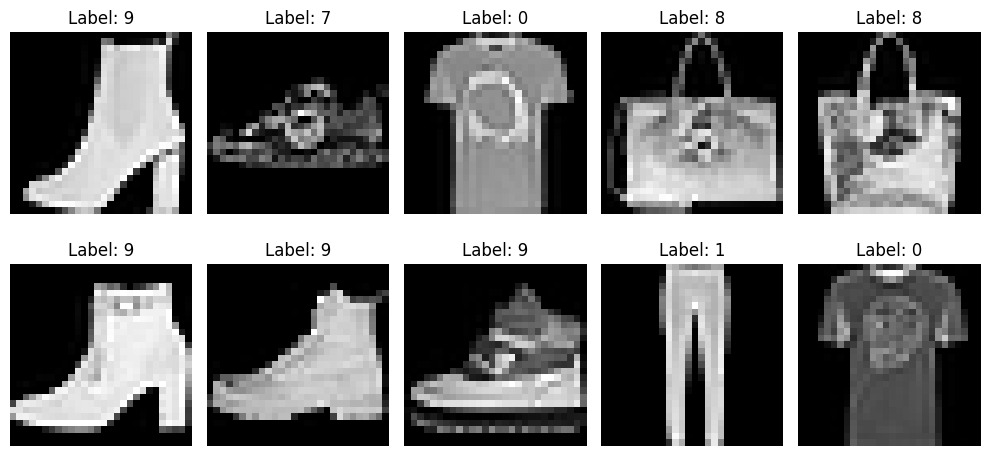

In [7]:
# Data Visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {df.iloc[i, 0]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Data Split
X = df.drop('label', axis=1).values
y = df['label'].values

In [9]:
X.shape

(6000, 784)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for balanced classes
)

In [11]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
# Custom Dataset Class
import torch
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]



In [13]:
# train-test dataset object
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [14]:
# train-test dataloader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
# NN Class
import torch.nn as nn
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
  def forward(self, x):
    return self.model(x)

In [16]:
# Epochs and learning rate
e = 100
lr = 0.1

In [17]:
# class object
model = MyNN(X_train.shape[1])

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
import torch.optim as optim
optimizer = optim.SGD(model.parameters(), lr=lr)

In [18]:
# training loop
for epoch in range(e):
  total_epoch_loss = 0
  for batch_fetaures, batch_labels in train_dataloader:
    # forward pass
    ouputs = model(batch_fetaures)
    loss = criterion(ouputs, batch_labels)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # Update parameters
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_dataloader)
  print(f'Epoch {epoch+1}/{e}, Loss: {avg_loss:.4f}')

Epoch 1/100, Loss: 1.4127
Epoch 2/100, Loss: 0.8087
Epoch 3/100, Loss: 0.6934
Epoch 4/100, Loss: 0.6068
Epoch 5/100, Loss: 0.5655
Epoch 6/100, Loss: 0.5190
Epoch 7/100, Loss: 0.4860
Epoch 8/100, Loss: 0.4652
Epoch 9/100, Loss: 0.4449
Epoch 10/100, Loss: 0.4303
Epoch 11/100, Loss: 0.4063
Epoch 12/100, Loss: 0.3864
Epoch 13/100, Loss: 0.3726
Epoch 14/100, Loss: 0.3494
Epoch 15/100, Loss: 0.3440
Epoch 16/100, Loss: 0.3325
Epoch 17/100, Loss: 0.3142
Epoch 18/100, Loss: 0.3172
Epoch 19/100, Loss: 0.2980
Epoch 20/100, Loss: 0.2815
Epoch 21/100, Loss: 0.2805
Epoch 22/100, Loss: 0.2710
Epoch 23/100, Loss: 0.2657
Epoch 24/100, Loss: 0.2537
Epoch 25/100, Loss: 0.2358
Epoch 26/100, Loss: 0.2400
Epoch 27/100, Loss: 0.2460
Epoch 28/100, Loss: 0.2241
Epoch 29/100, Loss: 0.2187
Epoch 30/100, Loss: 0.2155
Epoch 31/100, Loss: 0.2062
Epoch 32/100, Loss: 0.1980
Epoch 33/100, Loss: 0.1962
Epoch 34/100, Loss: 0.1875
Epoch 35/100, Loss: 0.1821
Epoch 36/100, Loss: 0.1741
Epoch 37/100, Loss: 0.1746
Epoch 38/1